In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

In [2]:
# ================================
# STEP 1: Upload and Read Dataset
# ================================

import pandas as pd
from google.colab import files

# Upload the dataset
uploaded = files.upload()

# Read the uploaded CSV file
data = pd.read_csv(next(iter(uploaded)))

# Display first 5 rows
print("First 5 Rows of Dataset:")
display(data.head())

# Display dataset information
print("\nDataset Information:")
data.info()

# Display shape
print("\nDataset Shape:", data.shape)

# Display column names
print("\nColumns:", data.columns.tolist())

# Display data types
print("\nData Types:")
print(data.dtypes)

Saving climate_data.csv to climate_data.csv
First 5 Rows of Dataset:


,Year,Temperature,CO2
0,1960,13.96,9580
1,1961,13.98,9780
2,1962,14.00,10000
3,1963,14.02,10240
4,1964,14.04,10420



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         65 non-null     int64  
 1   Temperature  65 non-null     float64
 2   CO2          65 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 1.7 KB

Dataset Shape: (65, 3)

Columns: ['Year', 'Temperature', 'CO2']

Data Types:
Year             int64
Temperature    float64
CO2              int64
dtype: object


In [3]:
# ==========================================
# STEP 2 : DATA PREPROCESSING
# ==========================================

print("="*50)
print("DATASET INFORMATION")
print("="*50)

data.info()

print("\n" + "="*50)
print("FIRST 5 ROWS")
print("="*50)

display(data.head())

print("\n" + "="*50)
print("LAST 5 ROWS")
print("="*50)

display(data.tail())

print("\n" + "="*50)
print("DATASET SHAPE")
print("="*50)

print("Rows :", data.shape[0])
print("Columns :", data.shape[1])

print("\n" + "="*50)
print("COLUMN NAMES")
print("="*50)

print(data.columns.tolist())

print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)

print(data.isnull().sum())

print("\n" + "="*50)
print("DUPLICATE VALUES")
print("="*50)

print("Duplicate Rows :", data.duplicated().sum())

# Remove duplicate rows
data = data.drop_duplicates()

print("\nDuplicates removed successfully.")

print("\n" + "="*50)
print("STATISTICAL SUMMARY")
print("="*50)

display(data.describe())

print("\n" + "="*50)
print("DATA TYPES")
print("="*50)

print(data.dtypes)

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         65 non-null     int64  
 1   Temperature  65 non-null     float64
 2   CO2          65 non-null     int64  
dtypes: float64(1), int64(2)
memory usage: 1.7 KB

FIRST 5 ROWS


,Year,Temperature,CO2
0,1960,13.96,9580
1,1961,13.98,9780
2,1962,14.00,10000
3,1963,14.02,10240
4,1964,14.04,10420



LAST 5 ROWS


,Year,Temperature,CO2
60,2020,15.04,22180
61,2021,15.06,22380
62,2022,15.08,22600
63,2023,15.10,22840
64,2024,15.12,23020



DATASET SHAPE
Rows : 65
Columns : 3

COLUMN NAMES
['Year', 'Temperature', 'CO2']

MISSING VALUES
Year           0
Temperature    0
CO2            0
dtype: int64

DUPLICATE VALUES
Duplicate Rows : 0

Duplicates removed successfully.

STATISTICAL SUMMARY


,Year,Temperature,CO2
count,65.00000,65.000000,65.000000
mean,1992.00000,14.540000,16304.923077
std,18.90767,0.340565,3971.168013
min,1960.00000,13.960000,9580.000000
25%,1976.00000,14.250000,12940.000000
50%,1992.00000,14.540000,16300.000000
75%,2008.00000,14.830000,19660.000000
max,2024.00000,15.120000,23020.000000



DATA TYPES
Year             int64
Temperature    float64
CO2              int64
dtype: object


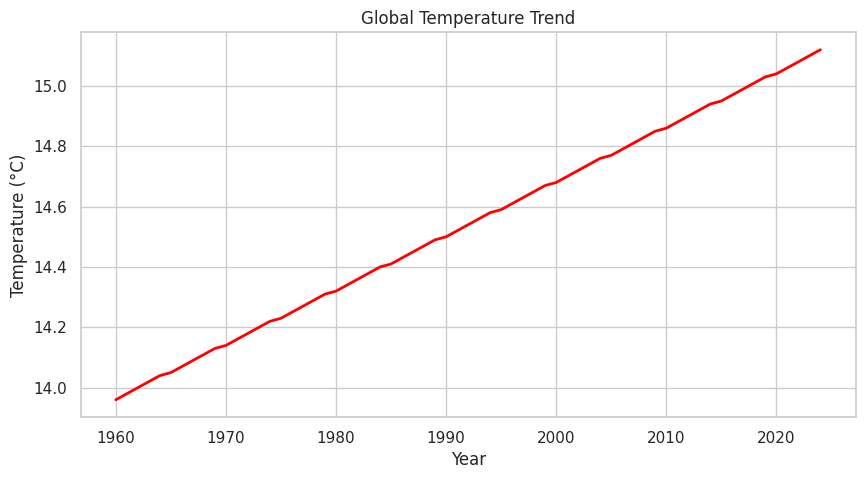

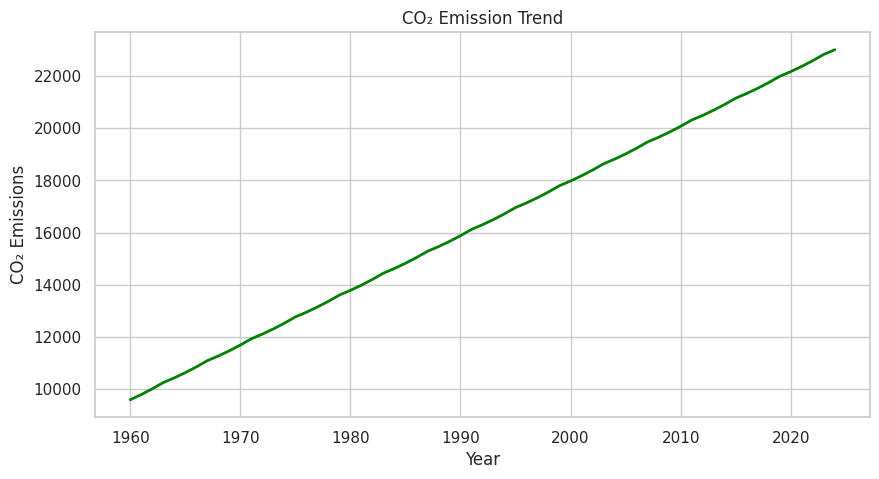

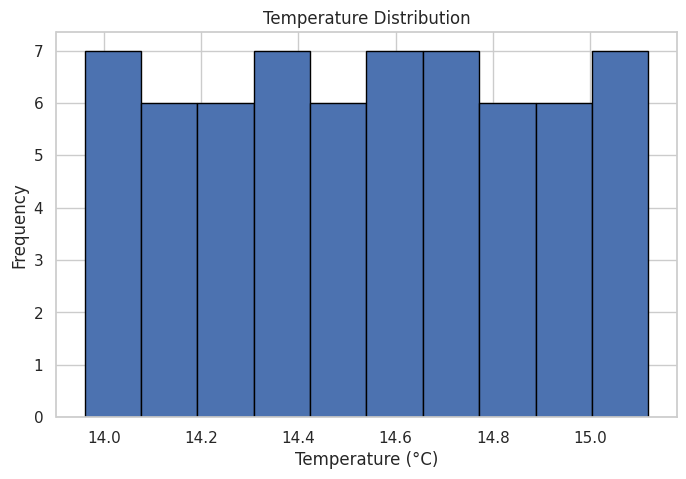

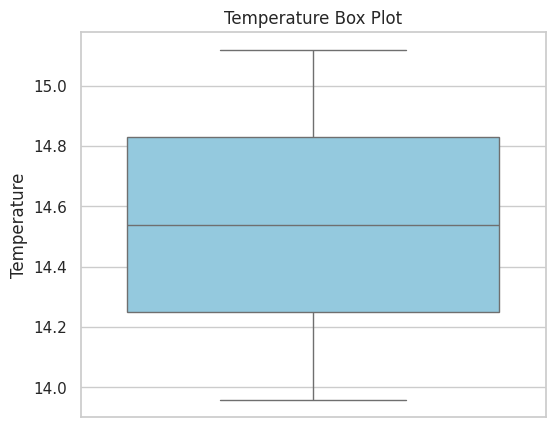

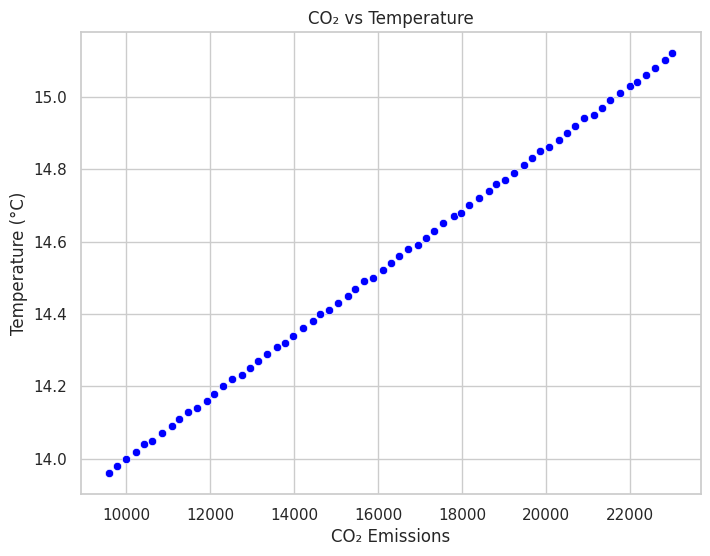

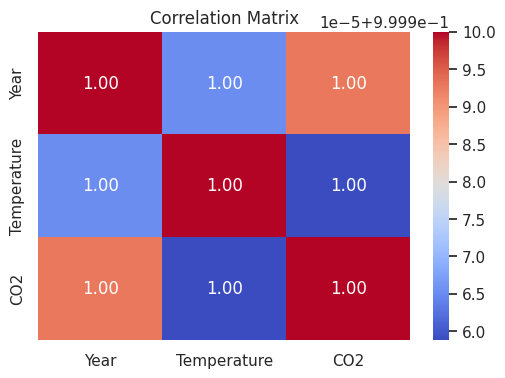

In [4]:
# ==========================================
# STEP 3 : EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set graph style
sns.set(style="whitegrid")

# ------------------------------------------
# 1. Temperature Trend Over Years
# ------------------------------------------
plt.figure(figsize=(10,5))
plt.plot(data["Year"], data["Temperature"], color="red", linewidth=2)
plt.title("Global Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

# ------------------------------------------
# 2. CO2 Emission Trend Over Years
# ------------------------------------------
plt.figure(figsize=(10,5))
plt.plot(data["Year"], data["CO2"], color="green", linewidth=2)
plt.title("CO₂ Emission Trend")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions")
plt.grid(True)
plt.show()

# ------------------------------------------
# 3. Histogram
# ------------------------------------------
plt.figure(figsize=(8,5))
data["Temperature"].hist(bins=10, edgecolor="black")
plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------
# 4. Box Plot
# ------------------------------------------
plt.figure(figsize=(6,5))
sns.boxplot(y=data["Temperature"], color="skyblue")
plt.title("Temperature Box Plot")
plt.show()

# ------------------------------------------
# 5. Scatter Plot
# ------------------------------------------
plt.figure(figsize=(8,6))
sns.scatterplot(data=data, x="CO2", y="Temperature", color="blue")
plt.title("CO₂ vs Temperature")
plt.xlabel("CO₂ Emissions")
plt.ylabel("Temperature (°C)")
plt.show()

# ------------------------------------------
# 6. Correlation Heatmap
# ------------------------------------------
plt.figure(figsize=(6,4))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [5]:
# ==========================================
# STEP 4 : FEATURE SELECTION & TRAIN-TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

# ----------------------------
# Feature Selection
# ----------------------------

X = data[['Year', 'CO2']]        # Input Features
y = data['Temperature']          # Target Variable

print("=" * 50)
print("FEATURES (X)")
print("=" * 50)
display(X.head())

print("=" * 50)
print("TARGET (y)")
print("=" * 50)
display(y.head())

# ----------------------------
# Train-Test Split
# ----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\n" + "=" * 50)
print("TRAINING DATA SHAPE")
print("=" * 50)
print("X_train :", X_train.shape)
print("y_train :", y_train.shape)

print("\n" + "=" * 50)
print("TESTING DATA SHAPE")
print("=" * 50)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

FEATURES (X)


,Year,CO2
0,1960,9580
1,1961,9780
2,1962,10000
3,1963,10240
4,1964,10420


TARGET (y)


,Temperature
0,13.96
1,13.98
2,14.00
3,14.02
4,14.04



TRAINING DATA SHAPE
X_train : (52, 2)
y_train : (52,)

TESTING DATA SHAPE
X_test : (13, 2)
y_test : (13,)


In [6]:
# ==========================================
# STEP 5 : BUILD & TRAIN MACHINE LEARNING MODEL
# ==========================================

from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("=" * 50)
print("MODEL TRAINING COMPLETED SUCCESSFULLY")
print("=" * 50)

# Display model coefficients
print("\nIntercept:")
print(model.intercept_)

print("\nFeature Coefficients:")

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

display(coefficients)

MODEL TRAINING COMPLETED SUCCESSFULLY

Intercept:
-23.736037095290015

Feature Coefficients:


,Feature,Coefficient
0,Year,0.019264
1,CO2,-0.000006


In [7]:
# ==========================================
# STEP 6 : MODEL PREDICTION & EVALUATION
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on test data
y_pred = model.predict(X_test)

# Create comparison table
results = pd.DataFrame({
    "Actual Temperature": y_test.values,
    "Predicted Temperature": y_pred
})

print("="*60)
print("ACTUAL VS PREDICTED TEMPERATURE")
print("="*60)

display(results.head(10))

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

print(f"Mean Absolute Error (MAE) : {mae:.4f}")
print(f"Mean Squared Error (MSE)  : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")

ACTUAL VS PREDICTED TEMPERATURE


,Actual Temperature,Predicted Temperature
0,14.92,14.918570
1,15.04,15.044575
2,13.96,13.964021
3,14.77,14.774496
4,14.05,14.054127
5,15.06,15.062644
6,14.25,14.252169
7,14.18,14.180132
8,15.12,15.116612
9,14.50,14.504298



MODEL EVALUATION
Mean Absolute Error (MAE) : 0.0030
Mean Squared Error (MSE)  : 0.0000
Root Mean Squared Error (RMSE) : 0.0033
R² Score : 0.9999


ACTUAL VS PREDICTED TEMPERATURE


,Actual Temperature,Predicted Temperature
0,14.92,14.918570
1,15.04,15.044575
2,13.96,13.964021
3,14.77,14.774496
4,14.05,14.054127
5,15.06,15.062644
6,14.25,14.252169
7,14.18,14.180132
8,15.12,15.116612
9,14.50,14.504298



MODEL PERFORMANCE
Mean Absolute Error (MAE)       : 0.0030
Mean Squared Error (MSE)        : 0.0000
Root Mean Squared Error (RMSE)  : 0.0033
R² Score                        : 0.9999


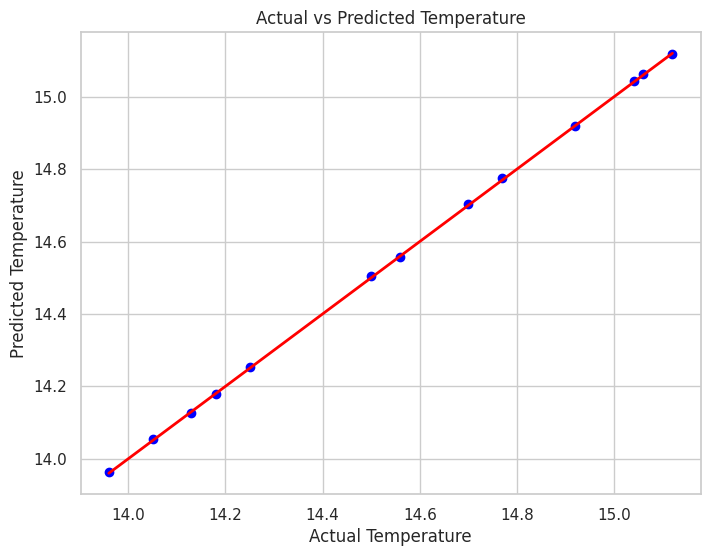

In [8]:
# ==========================================
# STEP 7 : MODEL EVALUATION
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict using the test dataset
y_pred = model.predict(X_test)

# ------------------------------------------
# Compare Actual vs Predicted
# ------------------------------------------

results = pd.DataFrame({
    "Actual Temperature": y_test.values,
    "Predicted Temperature": y_pred
})

print("=" * 60)
print("ACTUAL VS PREDICTED TEMPERATURE")
print("=" * 60)

display(results)

# ------------------------------------------
# Calculate Evaluation Metrics
# ------------------------------------------

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"Mean Absolute Error (MAE)       : {mae:.4f}")
print(f"Mean Squared Error (MSE)        : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE)  : {rmse:.4f}")
print(f"R² Score                        : {r2:.4f}")

# ------------------------------------------
# Actual vs Predicted Scatter Plot
# ------------------------------------------

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.grid(True)

plt.show()

In [9]:
# ==========================================
# STEP 8 : FUTURE TEMPERATURE PREDICTION
# ==========================================

# Future climate data
future_data = pd.DataFrame({
    "Year": [2025, 2030, 2035, 2040, 2045, 2050],
    "CO2": [23200, 24000, 24800, 25600, 26400, 27200]
})

# Predict future temperatures
future_data["Predicted Temperature"] = model.predict(future_data)

print("=" * 60)
print("FUTURE TEMPERATURE PREDICTIONS")
print("=" * 60)

display(future_data)

FUTURE TEMPERATURE PREDICTIONS


,Year,CO2,Predicted Temperature
0,2025,23200,15.13480
1,2030,24000,15.22634
2,2035,24800,15.31788
3,2040,25600,15.40942
4,2045,26400,15.50096
5,2050,27200,15.59250


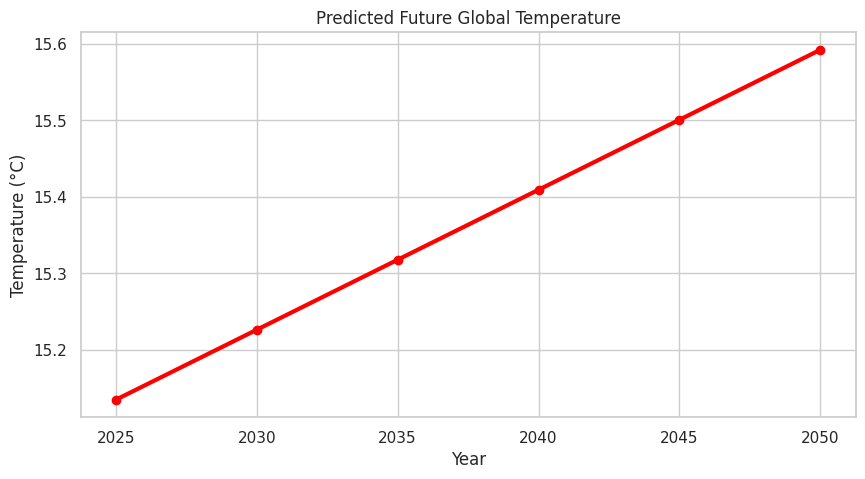

In [10]:
# ==========================================
# STEP 9 : VISUALIZE FUTURE PREDICTIONS
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(
    future_data["Year"],
    future_data["Predicted Temperature"],
    marker="o",
    linewidth=3,
    color="red"
)

plt.title("Predicted Future Global Temperature")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True)

plt.show()

In [11]:
# ==========================================
# STEP 10 : SAVE MACHINE LEARNING MODEL
# ==========================================

import joblib

joblib.dump(model, "Climate_Change_Model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [12]:
from google.colab import files

files.download("Climate_Change_Model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
# ==========================================
# STEP 11 : SAVE FUTURE PREDICTIONS
# ==========================================

future_data.to_csv("Future_Temperature_Predictions.csv", index=False)

print("Prediction file saved successfully.")

Prediction file saved successfully.


In [14]:
from google.colab import files

files.download("Future_Temperature_Predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>